In [90]:
import re
import string
from typing import cast, Any

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, LearningCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

import pandas as pd
pd.options.mode.chained_assignment = None

# **Data Pre-Processing & Labeling**

##### 1. Drop Null value rows and duplicates

In [91]:
df = pd.read_csv('../dataset/movie_reviews.csv')

# Remove any Null value rows and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.DataFrame'>
Index: 23820 entries, 0 to 25209
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    23820 non-null  str    
 1   content  23820 non-null  str    
 2   rating   23820 non-null  float64
dtypes: float64(1), str(2)
memory usage: 744.4 KB


##### 2. Combine review 'title' and 'content' into 'full_text'

In [92]:
df['full_text'] = df['title'] + ' ' + df['content']
df.info()

<class 'pandas.DataFrame'>
Index: 23820 entries, 0 to 25209
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      23820 non-null  str    
 1   content    23820 non-null  str    
 2   rating     23820 non-null  float64
 3   full_text  23820 non-null  str    
dtypes: float64(1), str(3)
memory usage: 930.5 KB


##### 3. Apply sentiment labelling according to review ratings
(1 - 4)  : Negative\
(5 - 6)  : Neutral\
(7 - 10) : Positive

In [93]:
def sentiment_labeling(rating):
    polarity = ''
    
    if rating <= 4:
        polarity = 'negative'
    elif rating >= 7:
        polarity = 'positive'
    else:
        polarity = 'neutral'
        
    return polarity

In [94]:
results = df['rating'].apply(sentiment_labeling)
df['polarity'] = results
df['polarity'].value_counts()

polarity
positive    11995
negative     8501
neutral      3324
Name: count, dtype: int64

##### 4. Apply data cleaning
Steps:
1. clean text (remove numbers, speial characters, new lines, punctuations, and spaces)
2. casefolding (lowercase)
3. tokenize
4. remove english stopwords
5. stemming
6. lemmatizing
7. convert back to whole string

In [95]:
def cleaning_text(text):
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove special characters
 
    text = text.replace('\n', ' ') # remove new lines
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuations
    text = text.strip(' ') # trimming
    return text
 
def casefolding_text(text):
    text = text.lower()
    return text
 
def tokenizing_text(text):
    text = word_tokenize(text)
    return text
 
def stopword_text(text):
    listStopwords = set(stopwords.words('english'))
    listStopwords.update(listStopwords)
    filtered = [word for word in text if word not in listStopwords]
    return filtered
 
def stemming_text(text):
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(word) for word in text]
    return stemmed

def lemmatizing_text(text):
    lemmer = WordNetLemmatizer()
    lemmatized = [lemmer.lemmatize(word) for word in text]
    return lemmatized
 
def to_sentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [96]:
clean_df = df
clean_df['clean_text'] = clean_df['full_text'].apply(cleaning_text)
clean_df['casefold_text'] = clean_df['clean_text'].apply(casefolding_text)
clean_df['tokenized_text'] = clean_df['casefold_text'].apply(tokenizing_text)
clean_df['stopword_text'] = clean_df['tokenized_text'].apply(stopword_text)

clean_df['stemmed_text'] = clean_df['stopword_text'].apply(stemming_text)
clean_df['lemmatized_text'] = clean_df['stopword_text'].apply(lemmatizing_text)

clean_df['stemmed_full_text'] = clean_df['stemmed_text'].apply(to_sentence)
clean_df['lemmatized_full_text'] = clean_df['lemmatized_text'].apply(to_sentence)
clean_df['final_full_text'] = clean_df['stopword_text'].apply(to_sentence)

In [97]:
clean_df.head()

,title,content,rating,full_text,polarity,clean_text,casefold_text,tokenized_text,stopword_text,stemmed_text,lemmatized_text,stemmed_full_text,lemmatized_full_text,final_full_text
0,The death of a franchise.,The Last Jedi is a well-made film; it's visual...,6.0,The death of a franchise. The Last Jedi is a w...,neutral,The death of a franchise The Last Jedi is a we...,the death of a franchise the last jedi is a we...,"[the, death, of, a, franchise, the, last, jedi...","[death, franchise, last, jedi, wellmade, film,...","[death, franchis, last, jedi, wellmad, film, v...","[death, franchise, last, jedi, wellmade, film,...",death franchis last jedi wellmad film visual s...,death franchise last jedi wellmade film visual...,death franchise last jedi wellmade film visual...
1,Worst Star Wars movie,Why is Luke being annihilated like this? After...,6.0,Worst Star Wars movie Why is Luke being annihi...,neutral,Worst Star Wars movie Why is Luke being annihi...,worst star wars movie why is luke being annihi...,"[worst, star, wars, movie, why, is, luke, bein...","[worst, star, wars, movie, luke, annihilated, ...","[worst, star, war, movi, luke, annihil, like, ...","[worst, star, war, movie, luke, annihilated, l...",worst star war movi luke annihil like number h...,worst star war movie luke annihilated like num...,worst star wars movie luke annihilated like nu...
2,It's bad. I don't know why people defend it.,I really want to sit across from Rian Johnson ...,6.0,It's bad. I don't know why people defend it. I...,neutral,Its bad I dont know why people defend it I rea...,its bad i dont know why people defend it i rea...,"[its, bad, i, dont, know, why, people, defend,...","[bad, dont, know, people, defend, really, want...","[bad, dont, know, peopl, defend, realli, want,...","[bad, dont, know, people, defend, really, want...",bad dont know peopl defend realli want sit acr...,bad dont know people defend really want sit ac...,bad dont know people defend really want sit ac...
4,Amazed by the negativity,I walked out of this movie with six friends at...,9.0,Amazed by the negativity I walked out of this ...,positive,Amazed by the negativity I walked out of this ...,amazed by the negativity i walked out of this ...,"[amazed, by, the, negativity, i, walked, out, ...","[amazed, negativity, walked, movie, six, frien...","[amaz, neg, walk, movi, six, friend, us, wire,...","[amazed, negativity, walked, movie, six, frien...",amaz neg walk movi six friend us wire adrenali...,amazed negativity walked movie six friend u wi...,amazed negativity walked movie six friends us ...
5,Almost Garbage,"""Star Wars: The Last Jedi"" was a huge disappoi...",6.0,"Almost Garbage ""Star Wars: The Last Jedi"" was ...",neutral,Almost Garbage Star Wars The Last Jedi was a h...,almost garbage star wars the last jedi was a h...,"[almost, garbage, star, wars, the, last, jedi,...","[almost, garbage, star, wars, last, jedi, huge...","[almost, garbag, star, war, last, jedi, huge, ...","[almost, garbage, star, war, last, jedi, huge,...",almost garbag star war last jedi huge disappoi...,almost garbage star war last jedi huge disappo...,almost garbage star wars last jedi huge disapp...


##### 5. Class balancing

In [98]:
clean_df = clean_df[clean_df['polarity'] != 'neutral']

# neutral_df = clean_df[clean_df['polarity'] == 'neutral'].head(3300)
positive_df = clean_df[clean_df['polarity'] == 'positive'].head(8000)
negative_df = clean_df[clean_df['polarity'] == 'negative'].head(8000)

clean_df = pd.concat([positive_df, negative_df])

clean_df['polarity'].value_counts()

polarity
positive    8000
negative    8000
Name: count, dtype: int64

In [99]:
def convert_polarity(polarity):
    return 1 if polarity == 'positive' else 0

In [100]:
X = clean_df['lemmatized_full_text']
Y = clean_df['polarity'].apply(convert_polarity)

# **Model Pipeline**

- Split: 70% training / 30% testing
- Feature extraction: TF-IDF vectorization
- Model: Random Forest Classifier

In [101]:
rm_X_train_raw, rm_X_test_raw, rm_Y_train, rm_Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

tfidf_model = TfidfVectorizer(max_features=5_000, ngram_range=(1, 3))
rm_X_train = tfidf_model.fit_transform(rm_X_train_raw)
rm_X_test = tfidf_model.transform(rm_X_test_raw)

In [102]:
rm_pipeline = Pipeline([
    ('rm', RandomForestClassifier())
])

param_grid = {
    'rm__n_estimators': [200],
    'rm__max_depth': [20, 25, 30],
    'rm__min_samples_leaf': [2],
}

grid_search = GridSearchCV(
    rm_pipeline, 
    param_grid, 
    cv=5, 
    n_jobs=-1, 
    verbose=2, 
    return_train_score=True
)

grid_search.fit(rm_X_train, rm_Y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END rm__max_depth=20, rm__min_samples_leaf=2, rm__n_estimators=200; total time=   7.3s
[CV] END rm__max_depth=20, rm__min_samples_leaf=2, rm__n_estimators=200; total time=   8.2s
[CV] END rm__max_depth=20, rm__min_samples_leaf=2, rm__n_estimators=200; total time=   8.9s
[CV] END rm__max_depth=20, rm__min_samples_leaf=2, rm__n_estimators=200; total time=   8.9s
[CV] END rm__max_depth=20, rm__min_samples_leaf=2, rm__n_estimators=200; total time=   9.9s
[CV] END rm__max_depth=25, rm__min_samples_leaf=2, rm__n_estimators=200; total time=  11.0s
[CV] END rm__max_depth=25, rm__min_samples_leaf=2, rm__n_estimators=200; total time=  11.1s
[CV] END rm__max_depth=25, rm__min_samples_leaf=2, rm__n_estimators=200; total time=  11.2s
[CV] END rm__max_depth=25, rm__min_samples_leaf=2, rm__n_estimators=200; total time=  11.8s
[CV] END rm__max_depth=25, rm__min_samples_leaf=2, rm__n_estimators=200; total time=  12.2s
[CV] END rm__max_dep

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rm__max_depth': [20, 25, ...], 'rm__min_samples_leaf': [2], 'rm__n_estimators': [200]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index

# Model Evaluation

#### 1. Classification Metrics

In [103]:
grid_search_pred = grid_search.predict(cast(Any, rm_X_test))

# Classification Metrics
print(classification_report(
    rm_Y_test, 
    grid_search_pred, 
    labels=[0, 1],
    target_names=['Negative', 'Positive']
))


              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      2388
    Positive       0.86      0.86      0.86      2412

    accuracy                           0.86      4800
   macro avg       0.86      0.86      0.86      4800
weighted avg       0.86      0.86      0.86      4800



#### 2. Confusion Matrix

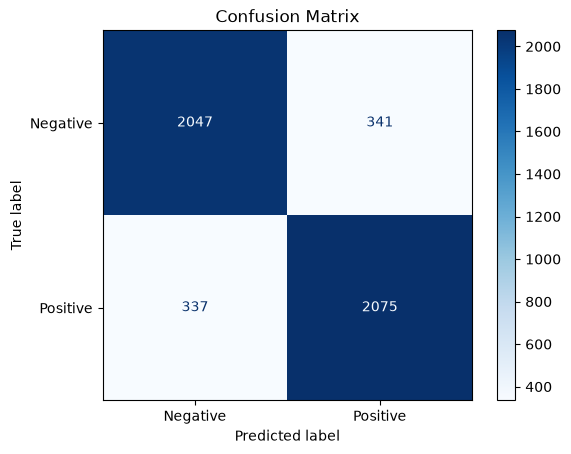

In [104]:
cm = confusion_matrix(rm_Y_test, grid_search_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

#### 3. Learning Curve

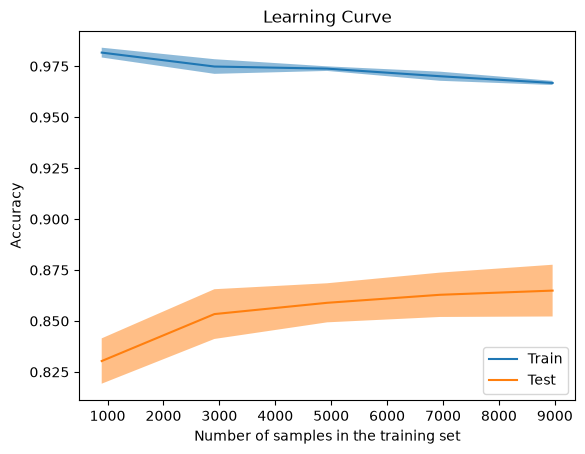

In [105]:
best_pipeline = grid_search.best_estimator_

LearningCurveDisplay.from_estimator(
    estimator=best_pipeline,
    X=rm_X_train,
    y=rm_Y_train, 
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5, 
    scoring="accuracy",
    score_type="both",
    n_jobs=-1
)

plt.title("Learning Curve")
plt.show()

# Inference

In [106]:
def predict_sentiment(text, rm_model):
    cleaned = cleaning_text(text)
    casefolded = casefolding_text(cleaned)
    tokens = tokenizing_text(casefolded)
    tokens = stopword_text(tokens)
    tokens = lemmatizing_text(tokens)
    
    sentence = to_sentence(tokens)
    vectorized_text = tfidf_model.transform([sentence])
    prediction = rm_model.predict(vectorized_text)[0]
    label = 'positive' if prediction == 1 else 'negative'
    
    return label

In [107]:
reviews = [
    "It wasn't bad, but I wouldn't watch it again.",
    "The acting was great but the plot made no sense.",
    "I expected to hate it but ended up really enjoying it.",
    "Not the worst movie I've seen, but far from the best.",
    "This was an absolute masterpiece from start to finish, I couldn't look away for a second.",
    "A complete waste of time, the plot made no sense and the acting was wooden.",
    "It was okay, nothing special but not terrible either.",
    "The visuals were stunning but the story dragged on way too long.",
    "I went in with low expectations and ended up pleasantly surprised."
]

for idx, r in enumerate(reviews):
    label = predict_sentiment(r, grid_search)
    print(f"{idx + 1}. {r}\n  -> {label}\n")

1. It wasn't bad, but I wouldn't watch it again.
  -> negative

2. The acting was great but the plot made no sense.
  -> negative

3. I expected to hate it but ended up really enjoying it.
  -> negative

4. Not the worst movie I've seen, but far from the best.
  -> negative

5. This was an absolute masterpiece from start to finish, I couldn't look away for a second.
  -> negative

6. A complete waste of time, the plot made no sense and the acting was wooden.
  -> negative

7. It was okay, nothing special but not terrible either.
  -> negative

8. The visuals were stunning but the story dragged on way too long.
  -> negative

9. I went in with low expectations and ended up pleasantly surprised.
  -> negative

